# Polynomial Regression

**Polynomial Regression** extends linear regression by fitting a polynomial curve to the data.  
Instead of fitting `y = w·x + b`, we fit `y = w₁·x + w₂·x² + ... + wₙ·xⁿ + b`.

It is still **linear** in the coefficients (parameters), so we can use `LinearRegression` after transforming the features with `PolynomialFeatures`.

**When to use it:**
- Data shows a curved (non-linear) pattern
- Linear regression underfits the data (high bias)


## 1. Imports

In [5]:
import numpy as np                              # Numerical operations
import pandas as pd                             # Data manipulation
import matplotlib.pyplot as plt                 # Plotting
import seaborn as sns                           # Statistical visualizations

from sklearn.preprocessing import PolynomialFeatures  # Transforms x -> [1, x, x², x³, ...]
from sklearn.linear_model import LinearRegression      # Linear regression model
from sklearn.pipeline import Pipeline                  # Chain preprocessing + model together
from sklearn.model_selection import train_test_split, cross_val_score  # Data splitting & CV
from sklearn.metrics import mean_squared_error, r2_score               # Evaluation metrics

np.random.seed(42)  # Reproducibility

## 2. Generate Synthetic Non-Linear Data

We create data following a quadratic relationship:  
`y = 0.5·x² + x + 2 + noise`

This curve cannot be captured by a straight line — it needs a polynomial.

In [3]:
np.random.seed(42)

m = 100                                                          # Number of data points
X = 6 * np.random.rand(m, 1) - 3                                # X uniformly distributed in [-3, 3]
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)                 # Quadratic relationship + Gaussian noise

print("X shape:", X.shape)  # (100, 1)
print("y shape:", y.shape)  # (100, 1)
print("\nFirst 5 samples:")
print(pd.DataFrame({'X': X.ravel(), 'y': y.ravel()}).head())

X shape: (100, 1)
y shape: (100, 1)

First 5 samples:
          X         y
0 -0.752759  1.617611
1  2.704286  8.061859
2  1.391964  4.452506
3  0.591951  0.779585
4 -2.063888  1.846257


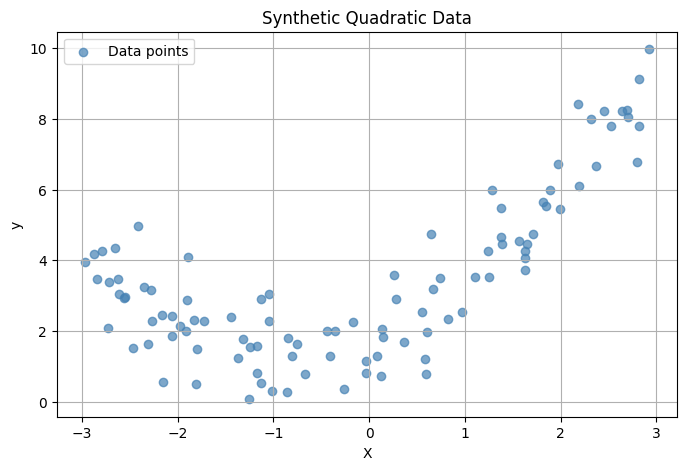

In [ ]:
plt.figure(figsize=(8, 5)) #    Set figure size to 8 inches wide and 5 inches tall
plt.scatter(X, y, alpha=0.7, color='steelblue', label='Data points')#    Scatter plot of X vs y with semi-transparent points and a label for the legend
plt.xlabel('X')                      #    Label for x-axis
plt.ylabel('y'                      )#    Label for y-axis
plt.title('Synthetic Quadratic Data')#    Title of the plot
plt.legend()                         #    Show legend to identify the data points
plt.grid(True)                       #    Add a grid for better readability    
plt.show()                           #     Display the plot

## 3. PolynomialFeatures — How It Works

`PolynomialFeatures(degree=d)` transforms a feature matrix by adding polynomial terms.

| Input `x` | degree=2 output | degree=3 output |
|-----------|------------------|-----------------|
| `[x]`     | `[1, x, x²]`    | `[1, x, x², x³]` |

The transformed features are then fed into `LinearRegression`.

In [ ]:
# Example: transform a simple array
X_sample = np.array([[2], [3]])  # Two data points: x=2 and x=3

poly = PolynomialFeatures(degree=3, include_bias=True)  # include_bias=True adds the constant column '1'
X_poly_sample = poly.fit_transform(X_sample)

print("Original X:")                                   #    Print the original input array
print(X_sample)                                        #     Original features for x=2 and x=3
print("\nTransformed X (degree=3): [1,  x,  x²,  x³]") #    Explanation of the new features
print(X_poly_sample)                                   #    Transformed features for x=2 and x=3
print("\nFeature names:", poly.get_feature_names_out())#    Names of the features in the transformed array

Original X:
[[2]
 [3]]

Transformed X (degree=3): [1,  x,  x²,  x³]
[[ 1.  2.  4.  8.]
 [ 1.  3.  9. 27.]]

Feature names: ['1' 'x0' 'x0^2' 'x0^3']


## 4. Fit Models of Different Degrees

We compare:
- **Degree 1** → Linear (underfitting)
- **Degree 2** → Quadratic (good fit)
- **Degree 10** → High-degree polynomial (overfitting)

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = [1, 2, 10]           # Polynomial degrees to compare
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)  # Smooth x-range for plotting the fitted curve

results = {}  # Store trained pipelines for evaluation

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, degree in zip(axes, degrees):
    # Build a pipeline: PolynomialFeatures → LinearRegression
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)    # Train the model
    results[degree] = pipeline        # Save the trained pipeline

    y_plot = pipeline.predict(X_plot) # Predict on smooth range for plotting

    ax.scatter(X_train, y_train, alpha=0.5, s=20, color='steelblue', label='Train')
    ax.scatter(X_test, y_test, alpha=0.5, s=20, color='orange', label='Test')
    ax.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Degree {degree}')
    ax.set_title(f'Degree = {degree}')
    ax.set_xlabel('X')
    ax.legend(fontsize=8)
    ax.set_ylim(-1, 12)
    ax.grid(True)

axes[0].set_ylabel('y')
plt.suptitle('Polynomial Regression: Different Degrees', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Model Evaluation

We compare the models using:
- **MSE** (Mean Squared Error) — lower is better
- **R²** — closer to 1 is better

We evaluate on both **train** and **test** sets to detect overfitting.

In [ ]:
print(f"{'Degree':<10} {'Train MSE':<15} {'Test MSE':<15} {'Train R²':<12} {'Test R²':<12}")
print("-" * 65)

for degree, pipeline in results.items():
    y_train_pred = pipeline.predict(X_train)   # Predictions on training data
    y_test_pred  = pipeline.predict(X_test)    # Predictions on test data

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse  = mean_squared_error(y_test,  y_test_pred)
    train_r2  = r2_score(y_train, y_train_pred)
    test_r2   = r2_score(y_test,  y_test_pred)

    print(f"{degree:<10} {train_mse:<15.4f} {test_mse:<15.4f} {train_r2:<12.4f} {test_r2:<12.4f}")

## 6. Bias-Variance Tradeoff

| Model | Bias | Variance | Problem |
|-------|------|----------|---------|
| Low degree (e.g. 1) | **High** | Low | Underfitting |
| Right degree (e.g. 2) | Low | Low | Good fit |
| High degree (e.g. 10) | Low | **High** | Overfitting |

**Learning curves** help us visualize bias and variance as a function of training size.

In [ ]:
def plot_learning_curves(model, X, y, ax, title):
    """Plot train and validation MSE vs. training set size."""
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    train_errors, val_errors = [], []

    for m_size in range(5, len(X_tr) + 1, 5):         # Increase training size step by step
        model.fit(X_tr[:m_size], y_tr[:m_size])        # Train on first m_size samples
        y_tr_pred  = model.predict(X_tr[:m_size])      # Predict on training slice
        y_val_pred = model.predict(X_val)               # Predict on validation set
        train_errors.append(mean_squared_error(y_tr[:m_size], y_tr_pred))
        val_errors.append(mean_squared_error(y_val, y_val_pred))

    ax.plot(range(5, len(X_tr) + 1, 5), np.sqrt(train_errors), label='Train RMSE', color='blue')
    ax.plot(range(5, len(X_tr) + 1, 5), np.sqrt(val_errors),   label='Val RMSE',   color='red')
    ax.set_title(title)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('RMSE')
    ax.set_ylim(0, 3)
    ax.legend()
    ax.grid(True)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, degree in zip(axes, [1, 2, 10]):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])
    plot_learning_curves(model, X, y, ax, title=f'Learning Curve — Degree {degree}')

plt.suptitle('Learning Curves (Bias vs. Variance)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Cross-Validation — Choosing the Best Degree

Cross-validation gives a reliable estimate of generalization error by averaging over multiple train/val splits.  
We use it to select the best polynomial degree automatically.

In [ ]:
degrees_to_test = range(1, 12)  # Test degrees from 1 to 11
cv_scores = []

for degree in degrees_to_test:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])
    # 5-fold cross-validation; scoring='neg_mean_squared_error' returns negative MSE
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # Convert to positive MSE

best_degree = list(degrees_to_test)[np.argmin(cv_scores)]  # Degree with lowest CV MSE

plt.figure(figsize=(9, 5))
plt.plot(degrees_to_test, cv_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_degree, color='red', linestyle='--', label=f'Best degree = {best_degree}')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV Mean Squared Error')
plt.title('Cross-Validation Error vs. Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best degree (lowest CV MSE): {best_degree}")

## 8. Regularization — Ridge Regression with Polynomial Features

High-degree polynomials can overfit. **Regularization** penalizes large coefficients:

- **Ridge (L2)**: adds `α · Σwᵢ²` to the loss → shrinks weights smoothly
- **Lasso (L1)**: adds `α · Σ|wᵢ|` to the loss → can zero out weights entirely

A larger `α` → stronger regularization → simpler model.

In [ ]:
from sklearn.linear_model import Ridge  # Ridge regression (L2 regularization)

alphas = [0, 0.01, 1, 100]             # Regularization strengths to compare
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, alpha in zip(axes, alphas):
    estimator = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=10, include_bias=False)),  # High degree to show overfitting risk
        ('model', estimator)
    ])
    pipeline.fit(X_train, y_train)
    y_plot = pipeline.predict(X_plot)

    ax.scatter(X_train, y_train, alpha=0.5, s=20, color='steelblue', label='Train')
    ax.scatter(X_test, y_test,   alpha=0.5, s=20, color='orange',    label='Test')
    ax.plot(X_plot, y_plot, color='red', linewidth=2)
    label = 'No reg.' if alpha == 0 else f'Ridge α={alpha}'
    ax.set_title(label)
    ax.set_xlabel('X')
    ax.set_ylim(-1, 12)
    ax.legend(fontsize=7)
    ax.grid(True)

axes[0].set_ylabel('y')
plt.suptitle('Effect of Ridge Regularization on Degree-10 Polynomial', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final Model — Best Degree with Evaluation Summary

In [ ]:
# Train the best-degree model on all training data
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('lin_reg', LinearRegression())
])
final_model.fit(X_train, y_train)

y_test_pred  = final_model.predict(X_test)
y_train_pred = final_model.predict(X_train)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_r2  = r2_score(y_train, y_train_pred)
test_r2   = r2_score(y_test,  y_test_pred)

print(f"Final model degree : {best_degree}")
print(f"Train MSE          : {train_mse:.4f}")
print(f"Test  MSE          : {test_mse:.4f}")
print(f"Train R²           : {train_r2:.4f}")
print(f"Test  R²           : {test_r2:.4f}")

# --- Plot final fit ---
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_plot = final_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, s=20, color='steelblue', label='Train')
plt.scatter(X_test,  y_test,  alpha=0.5, s=20, color='orange',    label='Test')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Poly degree={best_degree}')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Final Polynomial Regression (degree={best_degree})')
plt.legend()
plt.grid(True)
plt.show()

## 10. Residual Analysis

Residuals = `y_actual - y_predicted`.  
A good model has residuals that are **randomly scattered** around zero (no pattern).

In [ ]:
residuals = y_test.ravel() - y_test_pred.ravel()  # Compute residuals on the test set

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs. predicted values
ax1.scatter(y_test_pred, residuals, alpha=0.6, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted y')
ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs. Predicted')
ax1.grid(True)

# Distribution of residuals
ax2.hist(residuals, bins=20, color='steelblue', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution')
ax2.grid(True)

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean of residuals : {residuals.mean():.4f}  (should be ≈ 0)")
print(f"Std  of residuals : {residuals.std():.4f}")

## Summary

| Step | What we did |
|------|-------------|
| 1 | Generated quadratic synthetic data |
| 2 | Explored `PolynomialFeatures` transformation |
| 3 | Fitted models of degree 1, 2, 10 and visualized the fits |
| 4 | Evaluated with MSE and R² on train & test sets |
| 5 | Plotted learning curves to see bias–variance tradeoff |
| 6 | Used **cross-validation** to automatically choose the best degree |
| 7 | Applied **Ridge regularization** to control overfitting in high-degree models |
| 8 | Performed **residual analysis** to validate model assumptions |

**Key takeaway:**  
> Polynomial regression is powerful but prone to overfitting. Always validate with cross-validation and consider regularization for high degrees.